In [38]:
!pip install pandas

In [103]:
import random
import pandas as pd

In [104]:
# Generate "rng" random x values between 1 and "nums"
# These will act as the independent variable for our dataset
nums = 100
rng = 100
random.seed(42)
x = [random.randint(1,nums) for _ in range(rng)]

In [105]:
#Baseline parameters

w1 = 2
w0 = 1
mn = 0
std_dev = 5

In [106]:
#get y values
def get_xyn(x_list,w1,w0,mean = 0,std = 0):

    """
    Generates y values with and without noise.

    Parameters:
    x_list : list of x values
    w1 : slope
    w0 : intercept
    mean : mean of Gaussian noise (default = 0)
    std : standard deviation of Gaussian noise (default = 0)

    Returns:
    yn_list : y values with noise if std != 0 , otherwise does not add noise
    """
    
    yn_list = [
        (w1 * xi) + w0 + (np.random.normal(mean, std) if std != 0 else 0)
        for xi in x_list
    ]

    return yn_list

    

In [107]:
y_won = get_xyn(x,w1,w0)

In [123]:
assert len(y_won) == len(x)                                         #check length of y is same as x

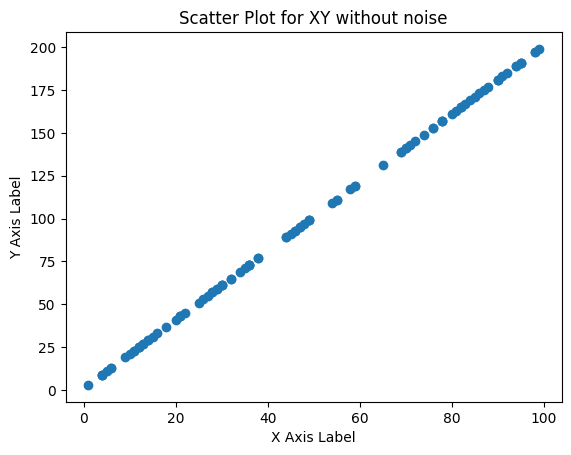

In [108]:
import matplotlib.pyplot as plt

plt.scatter(x, y_won)

plt.title("Scatter Plot for XY w")
plt.xlabel("X Axis Label")
plt.ylabel("Y Axis Label")
plt.show()


In [109]:
import numpy as np

def pred_w1w0(x_list, y_list):

    """
    Computes the best-fit slope (w1) and intercept (w0)
    using the closed-form least squares solution.

    Parameters:
    x_list : list of x values
    y_list : list of y values

    Returns:
    (w1_cal, w0_cal) : estimated slope and intercept
    """

    # Calculate mean of x and y
    x_mean = np.mean(x_list)
    y_mean = np.mean(y_list)

    #Initialize numerator and denominator to implement slope formula
    tot_num = 0
    tot_den = 0
    
    for i in range(len(x_list)):                       #calculate numerator and denominator component for each value of x
        
        num = (y_list[i] - y_mean)*x_list[i]
        den = (x_list[i] - x_mean)*x_list[i]
    
        tot_num = tot_num + num                       #running total for numerator
        tot_den = tot_den + den                       #running total for denominator
    
    w1_cal = tot_num/tot_den
    w0_cal = y_mean - (w1_cal*x_mean)

    #return estimated values for slope and intercept
    return (w1_cal, w0_cal)


In [110]:
est_w1, est_w0 = pred_w1w0(x, y_won)

In [111]:
print(est_w1, est_w0)

2.0 1.0


In [112]:
y_noise = get_xyn(x,w1,w0, mean = mn, std = std_dev)

In [126]:
# Check average deviation is reasonable
diff = np.mean([abs(a - b) for a, b in zip(y_won, y_noise)])

assert diff > 0, "Failed: Noise should introduce variation"                  #check if noise was added succesfully

In [127]:
assert len(y_noise) == len(x)

In [129]:
threshold_percent = 10

assert abs((est_w1 - w1) / w1) * 100 < threshold_percent                     #check if error is greater than 10%

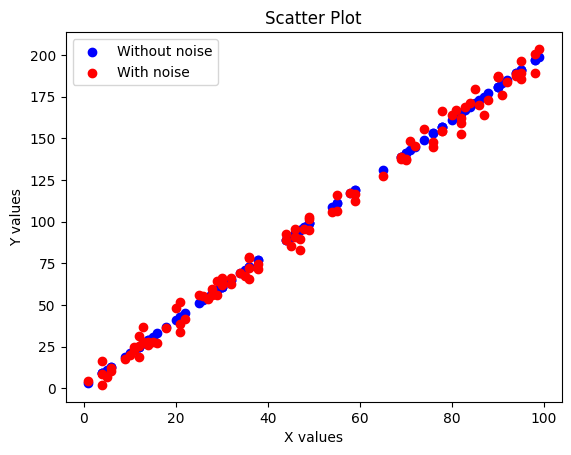

In [113]:
import matplotlib.pyplot as plt

plt.scatter(x, y_won, color='blue', label='Without noise')
plt.scatter(x, y_noise, color='red', label='With noise')

# Labels and title
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Scatter Plot")
plt.legend()

# Show plot
plt.show()

In [114]:
w1_pred, w0_pred = pred_w1w0(x,y_noise)

In [115]:
print(w1_pred, w0_pred)

1.9924074218611099 0.8142652106921417


In [116]:
def mse(y_true, y_pred):
    return sum((yt - yp)**2 for yt, yp in zip(y_true, y_pred)) / len(y_true)

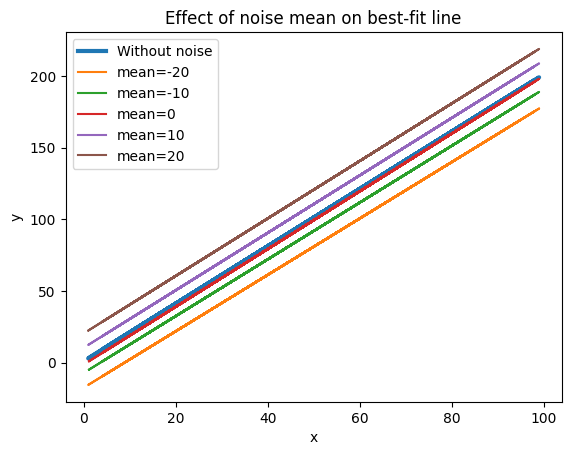

In [117]:
means = [-20,-10,0,10,20]
std_dev = 5
w1_pred_lst = []
w0_pred_lst = []
mse_mean = []
plt.figure()

plt.plot(x,y_won,label="Without noise",linewidth=3)

for m in means:

    y_noisy = get_xyn(x,w1,w0,m,std_dev)

    w1_pred,w0_pred = pred_w1w0(x,y_noisy)
    w1_pred_lst.append(w1_pred)
    w0_pred_lst.append(w0_pred)

    y_pred = get_xy(x,w1_pred,w0_pred)

    # MSE vs original (true line)
    mse_val = mse(y_won, y_pred)
    mse_mean.append(mse_val)

    plt.plot(x,y_pred,label=f"mean={m}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of noise mean on best-fit line")
plt.legend()

plt.show()

In [118]:
results_df = pd.DataFrame({
    "Mean": means,
    "Predicted Slope": w1_pred_lst,
    "Predicted Intercept": w0_pred_lst,
    "Slope Difference from Original": [pred - w1 for pred in w1_pred_lst],
    "Intercept Difference from Original": [pred - w0 for pred in w0_pred_lst],
    "MSE": mse_mean,
})

print(results_df)

   Mean  Predicted Slope  Predicted Intercept  Slope Difference from Original  \
0   -20         1.966903           -17.474010                       -0.033097   
1   -10         1.980028            -7.171313                       -0.019972   
2     0         2.013469            -1.368869                        0.013469   
3    10         2.003547            10.378895                        0.003547   
4    20         2.004465            20.379510                        0.004465   

   Intercept Difference from Original         MSE  
0                          -18.474010  404.707903  
1                           -8.171313   84.048657  
2                           -2.368869    3.088079  
3                            9.378895   91.258862  
4                           19.379510  384.094677  


This shows us that difference in mean for noise has very little effect on slope but a bigger impact on y-intercept.

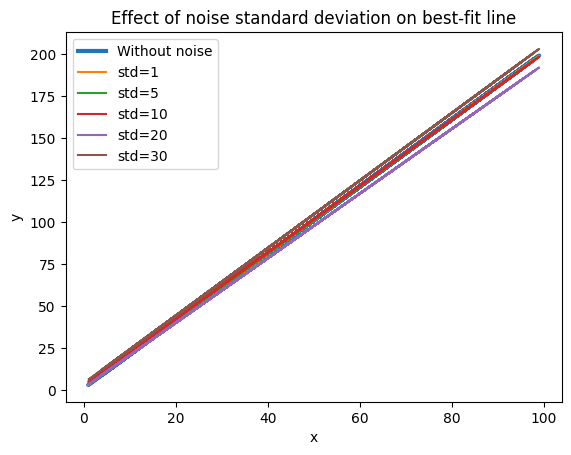

In [119]:
std_devs = [1, 5, 10, 20, 30]
mean = 0
w1_pred_lst = []
w0_pred_lst = []
mse_lst_std = []

plt.figure()

plt.plot(x, y_won, label="Without noise", linewidth=3)

for s in std_devs:
    y_noisy = get_xyn(x, w1, w0, mean, s)

    w1_pred, w0_pred = pred_w1w0(x, y_noisy)
    w1_pred_lst.append(w1_pred)
    w0_pred_lst.append(w0_pred)

    y_pred = get_xy(x, w1_pred, w0_pred)

    # MSE vs original (true line)
    mse_val = mse(y_won, y_pred)
    mse_lst_std.append(mse_val)

    plt.plot(x, y_pred, label=f"std={s}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of noise standard deviation on best-fit line")
plt.legend()
plt.show()

In [120]:
import pandas as pd

results_df = pd.DataFrame({
    "Std Dev": std_devs,
    "Original Slope": [w1] * len(std_devs),
    "Predicted Slope": w1_pred_lst,
    "Slope Difference": [pred - w1 for pred in w1_pred_lst],
    "Original Intercept": [w0] * len(std_devs),
    "Predicted Intercept": w0_pred_lst,
    "Intercept Difference": [pred - w0 for pred in w0_pred_lst],
    "MSE": mse_lst_std
})

print(results_df.round(4))

   Std Dev  Original Slope  Predicted Slope  Slope Difference  \
0        1               2           1.9979           -0.0021   
1        5               2           1.9883           -0.0117   
2       10               2           1.9723           -0.0277   
3       20               2           1.9251           -0.0749   
4       30               2           2.0094            0.0094   

   Original Intercept  Predicted Intercept  Intercept Difference      MSE  
0                   1               1.0445                0.0445   0.0076  
1                   1               1.6078                0.6078   0.1243  
2                   1               2.9862                1.9862   1.0909  
3                   1               1.3228                0.3228  16.2335  
4                   1               4.0217                3.0217  12.1888  


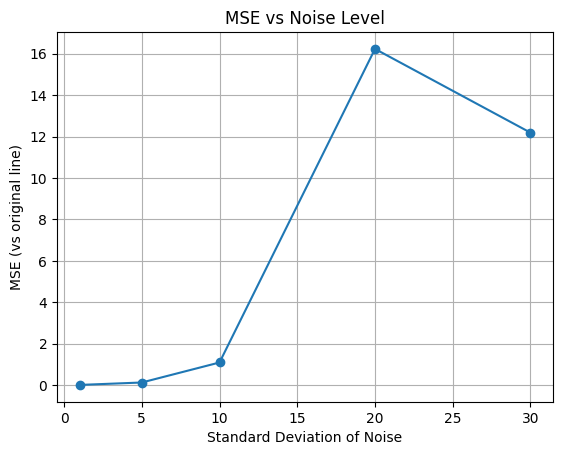

In [121]:
plt.figure()
plt.plot(std_devs, mse_lst_std, marker='o')

plt.xlabel("Standard Deviation of Noise")
plt.ylabel("MSE (vs original line)")
plt.title("MSE vs Noise Level")

plt.grid()
plt.show()

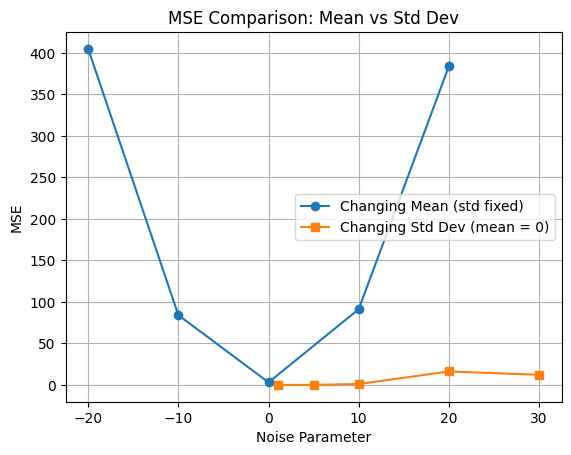

In [122]:
plt.figure()

plt.plot(means, mse_mean, marker='o', label="Changing Mean (std fixed)")
plt.plot(std_devs, mse_lst_std, marker='s', label="Changing Std Dev (mean = 0)")

plt.xlabel("Noise Parameter")
plt.ylabel("MSE")
plt.title("MSE Comparison: Mean vs Std Dev")

plt.legend()
plt.grid()

plt.show()
